# Dog Survey Data Cleaning Demo (Refactored Pipeline)

This notebook implements a structured data quality pipeline:

1. Completeness Analysis
2. Consistency Analysis
3. Duplicate Analysis
4. Cleaning Pipeline Execution
5. Before vs After Validation (Statistical + Visual)


In [449]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [450]:
import sys, os
sys.path.append(os.path.abspath('../../'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from src.scripts.profiling import dataset_summary, inconsistency_summary
from src.scripts.completeness import (
    completeness_summary, completeness_report,
    fix_title_completeness,
    fix_email_completeness,
    fix_amount_completeness,
    fix_dog_size_completeness,
    fix_dog_gender_completeness,
    fix_dog_age_completeness
)
from src.scripts.consistency import (
    inconsistency_summary, inconsistency_report,
    fix_title_consistency,
    fix_email_consistency,
    fix_amount_consistency,
    fix_dog_size_consistency,
    fix_dog_gender_consistency,
    fix_dog_age_consistency
)
from src.scripts.duplicates import (
    duplicate_summary,
    duplicate_report,
    remove_duplicates
)
from src.utils.helpers import (
    normalize_missing,
    drop_noise_columns,
    show_step_changes,
    show_duplicate_removal
)

sns.set(style="whitegrid")

## Phase 1 — Load Data

In [451]:
df = pd.read_csv('../../data/raw/dog_survey.csv', dtype=str, keep_default_na=False)
df.columns = df.columns.str.strip().str.lower()

df_before_drop = df.copy()

df = drop_noise_columns(df)
df = normalize_missing(df)

df_after_drop = df.copy()

df_before = df.copy()

print("\nBefore Drop: ")
display(df_before_drop)
print("\nAfter Drop: ")
display(df_after_drop)

display(dataset_summary(df, 'RAW DATA'))


Before Drop: 


,id,title,first_name,last_name,email,amount_spent_on_dog_food,dog_size,dog_gender,dog_age,unnamed: 9,unnamed: 10
0,1,Mrs,Frasquito,Dene,fdene0@dell.com,£80.05,S,M,53,,
1,2,Ms,Lawrence,Kardos,lkardos1@diigo.com,£66.30,XL,M,2,,
2,3,Rev,Lanna,Wintersgill,lwintersgill2@domainmarket.com,£25.84,L,F,71,,
3,4,Rev,Richmound,Kimmitt,rkimmitt3@jiathis.com,£50.76,M,M,9,,
4,5,Rev,Valeda,Dallender,vdallender4@theglobeandmail.com,£83.41,XL,F,23,,
...,...,...,...,...,...,...,...,...,...,...,...
303,296,Ms,Blake,Pryce,bpryce87@nasa.gov,£71.83,XL,F,94,,
304,297,Mrs,Damita,Fogden,dfogden88@fema.gov,£94.69,L,female,20,,
305,298,Honorable,Vladamir,Aynscombe,vaynscombe89@guardian.co.uk,£0.12,XL,M,55,,
306,299,Mr,Coralie,Gossington,cgossington8a@tumblr.com,£82.34,XL,F,42,,



After Drop: 


,id,title,first_name,last_name,email,amount_spent_on_dog_food,dog_size,dog_gender,dog_age
0,1,Mrs,Frasquito,Dene,fdene0@dell.com,£80.05,S,M,53
1,2,Ms,Lawrence,Kardos,lkardos1@diigo.com,£66.30,XL,M,2
2,3,Rev,Lanna,Wintersgill,lwintersgill2@domainmarket.com,£25.84,L,F,71
3,4,Rev,Richmound,Kimmitt,rkimmitt3@jiathis.com,£50.76,M,M,9
4,5,Rev,Valeda,Dallender,vdallender4@theglobeandmail.com,£83.41,XL,F,23
...,...,...,...,...,...,...,...,...,...
303,296,Ms,Blake,Pryce,bpryce87@nasa.gov,£71.83,XL,F,94
304,297,Mrs,Damita,Fogden,dfogden88@fema.gov,£94.69,L,female,20
305,298,Honorable,Vladamir,Aynscombe,vaynscombe89@guardian.co.uk,£0.12,XL,M,55
306,299,Mr,Coralie,Gossington,cgossington8a@tumblr.com,£82.34,XL,F,42


,Dataset,Rows,Columns,Missing Values,Duplicates
0,RAW DATA,308,9,51,8


## Phase 2 — Completeness Analysis

In [452]:
completeness_report(df, 'RAW DATA')
comp_before = completeness_summary(df)


=== COMPLETENESS REPORT: RAW DATA ===
Rows: 308
                          Missing Count  Missing %
title                                30       9.74
amount_spent_on_dog_food             12       3.90
dog_gender                            6       1.95
email                                 2       0.65
dog_age                               1       0.32
id                                    0       0.00
first_name                            0       0.00
last_name                             0       0.00
dog_size                              0       0.00

--- SAMPLE ROWS WITH MISSING VALUES ---

[title] missing examples (30 rows total)
    id title first_name last_name                      email  \
16  17   NaN     Karoly     Buxcy  kbuxcyg@howstuffworks.com   
24  25   NaN        Jay    Buckle       jbuckleo@archive.org   
33  34   NaN       Tera   Bresson       tbressonx@reddit.com   

   amount_spent_on_dog_food dog_size dog_gender dog_age  
16                   £68.00       XL       

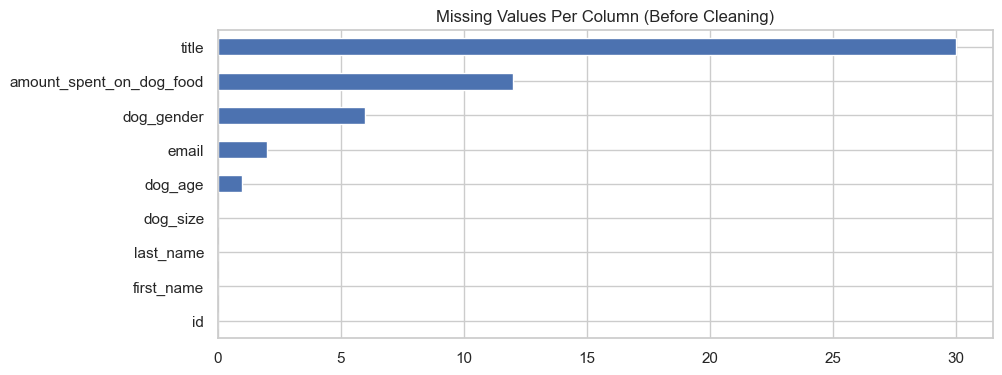

In [453]:
# Visualization — Missing Values
plt.figure(figsize=(10,4))
df.isna().sum().sort_values().plot(kind='barh')
plt.title('Missing Values Per Column (Before Cleaning)')
plt.show()

## Phase 3 — Consistency Analysis

In [454]:
summary_before, mask_before = inconsistency_summary(df)

In [455]:
inconsistency_report(df, 'RAW DATA')


=== INCONSISTENCY REPORT: RAW DATA ===
Rows: 308

--- SUMMARY TABLE ---
                Issue Count  Issue %
dog_size                307    99.68
dog_gender              299    97.08
amount_format            10     3.25
dog_age_format            4     1.30
email                     4     1.30

--- SAMPLE INCONSISTENT RECORDS ---

[dog_size] (307 rows)
  id title first_name    last_name                           email  \
0  1   Mrs  Frasquito         Dene                 fdene0@dell.com   
1  2    Ms   Lawrence       Kardos              lkardos1@diigo.com   
2  3   Rev      Lanna  Wintersgill  lwintersgill2@domainmarket.com   

  amount_spent_on_dog_food dog_size dog_gender dog_age  
0                   £80.05        S          M      53  
1                   £66.30       XL          M       2  
2                   £25.84        L          F      71  

[dog_gender] (299 rows)
  id title first_name    last_name                           email  \
0  1   Mrs  Frasquito         Dene       

,Issue Count,Issue %
dog_size,307,99.68
dog_gender,299,97.08
amount_format,10,3.25
dog_age_format,4,1.30
email,4,1.30


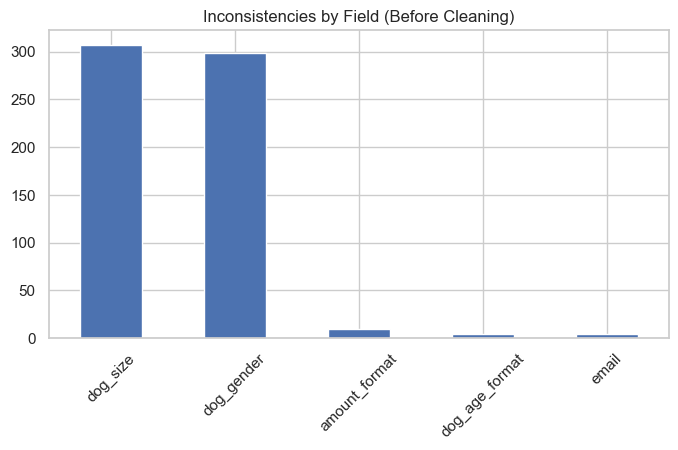

In [456]:
# Visualization — Inconsistencies
plt.figure(figsize=(8,4))
summary_before['Issue Count'].plot(kind='bar')
plt.title('Inconsistencies by Field (Before Cleaning)')
plt.xticks(rotation=45)
plt.show()

## Phase 4 — Duplicate Analysis

In [457]:
dup_summary_before, dup_rows_before, dup_groups_before = duplicate_summary(df)
duplicate_report(df, 'RAW DATA')


=== DUPLICATE REPORT: RAW DATA ===
Rows: 308

--- SUMMARY ---
   duplicate_count  duplicate_percentage
0               11                  3.57

--- DUPLICATE SAMPLE ROWS ---
      id title first_name  last_name                        email  \
179  180   Mrs   Laughton  Kingsmill  lkingsmill4z@slideshare.net   
180  180   Mrs   Laughton  Kingsmill  lkingsmill4z@slideshare.net   
222  222    Mr    Hillary     Fisbey    hfisbey65@marketwatch.com   
223  222    Mr    Hillary     Fisbey    hfisbey65@marketwatch.com   
224  222    Mr    Hillary     Fisbey    hfisbey65@marketwatch.com   

    amount_spent_on_dog_food dog_size dog_gender dog_age  
179                   £20.00        S       Male       5  
180                   £20.00        S       Male       5  
222                   £67.24        S          F      52  
223                   £67.24        S          F      52  
224                   £67.24        S          F      52  

--- GROUPED DUPLICATES (TOP 10) ---
    id title first

,duplicate_count,duplicate_percentage
0,11,3.57


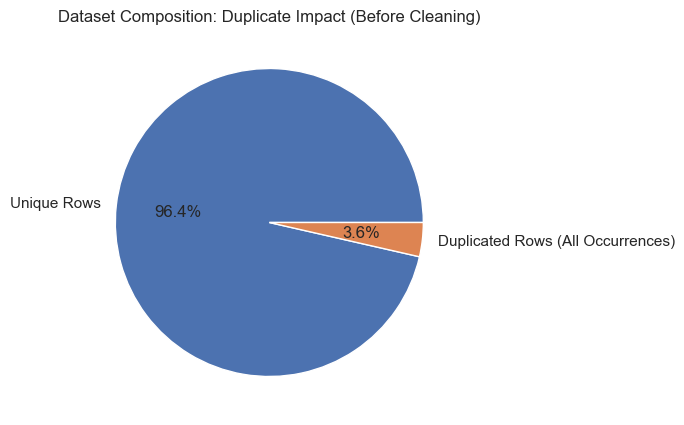

In [458]:
# Visualization — Duplicates
dup_mask = df_before.duplicated(keep=False)

dup_rows = dup_mask.sum()
total_rows = len(df_before)

unique_rows = total_rows - dup_rows

plt.figure(figsize=(5,5))
plt.pie(
    [unique_rows, dup_rows],
    labels=["Unique Rows", "Duplicated Rows (All Occurrences)"],
    autopct="%1.1f%%"
)

plt.title("Dataset Composition: Duplicate Impact (Before Cleaning)")
plt.show()

## Phase 5 — Cleaning Pipeline

In [459]:
total_changes = {}

# Remove duplicates
before = df.copy()
df, _ = remove_duplicates(df)
total_changes['duplicates_removed'] = show_duplicate_removal(before, df)


[STEP REPORT] Duplicate Removal
Total duplicate rows (before): 11

--- FULL DUPLICATE ROWS (BEFORE REMOVAL) ---
     id title first_name  last_name                        email  \
0   180   Mrs   Laughton  Kingsmill  lkingsmill4z@slideshare.net   
1   180   Mrs   Laughton  Kingsmill  lkingsmill4z@slideshare.net   
2   222    Mr    Hillary     Fisbey    hfisbey65@marketwatch.com   
3   222    Mr    Hillary     Fisbey    hfisbey65@marketwatch.com   
4   222    Mr    Hillary     Fisbey    hfisbey65@marketwatch.com   
5   222    Mr    Hillary     Fisbey    hfisbey65@marketwatch.com   
6   222    Mr    Hillary     Fisbey    hfisbey65@marketwatch.com   
7   222    Mr    Hillary     Fisbey    hfisbey65@marketwatch.com   
8   222    Mr    Hillary     Fisbey    hfisbey65@marketwatch.com   
9   237    Ms   Penelope     Stubbs   pstubbs6k@businesswire.com   
10  237    Ms   Penelope     Stubbs   pstubbs6k@businesswire.com   

   amount_spent_on_dog_food dog_size dog_gender dog_age  
0           

In [460]:
# Title
before = df.copy()
df = fix_title_completeness(df)
df = fix_title_consistency(df)
total_changes['title'] = show_step_changes('Title', before, df, ['title'])


[STEP REPORT] Title
Modified rows: 30

--- SAMPLE CHANGES ---
    title         
   before    after
id                
17    NaN  Unknown
25    NaN  Unknown
34    NaN  Unknown
37    NaN  Unknown
39    NaN  Unknown

--- CHANGE COUNT BY COLUMN ---
title    2
Name: count, dtype: int64


In [461]:
# Email
before = df.copy()
df = fix_email_completeness(df)
df = fix_email_consistency(df)
total_changes['email'] = show_step_changes('Email', before, df, ['email'])


[STEP REPORT] Email
Modified rows: 4

--- SAMPLE CHANGES ---
     email                   
    before              after
id                           
21     NaN  invalid@email.com
83      NA  invalid@email.com
165      -  invalid@email.com
208    NaN  invalid@email.com

--- CHANGE COUNT BY COLUMN ---
email    2
Name: count, dtype: int64


In [462]:
# Amount
before = df.copy()
df = fix_amount_completeness(df)
df = fix_amount_consistency(df)
total_changes['amount'] = show_step_changes('Amount', before, df, ['amount_spent_on_dog_food'])


[STEP REPORT] Amount
Modified rows: 300

--- SAMPLE CHANGES ---
   amount_spent_on_dog_food       
                     before  after
id                                
1                    £80.05  80.05
2                    £66.30  66.30
3                    £25.84  25.84
4                    £50.76  50.76
5                    £83.41  83.41

--- CHANGE COUNT BY COLUMN ---
amount_spent_on_dog_food    2
Name: count, dtype: int64


In [463]:
# Dog size
before = df.copy()
df = fix_dog_size_completeness(df)
df = fix_dog_size_consistency(df)
total_changes['dog_size'] = show_step_changes('Dog Size', before, df, ['dog_size'])


[STEP REPORT] Dog Size
Modified rows: 300

--- SAMPLE CHANGES ---
   dog_size             
     before        after
id                      
1         S        Small
2        XL  Extra Large
3         L        Large
4         M       Medium
5        XL  Extra Large

--- CHANGE COUNT BY COLUMN ---
dog_size    2
Name: count, dtype: int64


In [464]:
# Dog gender
before = df.copy()
df = fix_dog_gender_completeness(df)
df = fix_dog_gender_consistency(df)
total_changes['dog_gender'] = show_step_changes('Dog Gender', before, df, ['dog_gender'])


[STEP REPORT] Dog Gender
Modified rows: 295

--- SAMPLE CHANGES ---
   dog_gender        
       before   after
id                   
1           M    Male
2           M    Male
3           F  Female
4           M    Male
5           F  Female

--- CHANGE COUNT BY COLUMN ---
dog_gender    2
Name: count, dtype: int64


In [465]:
# Dog age
before = df.copy()
df = fix_dog_age_completeness(df)
df = fix_dog_age_consistency(df)
total_changes['dog_age'] = show_step_changes('Dog Age', before, df, ['dog_age'])


[STEP REPORT] Dog Age
Modified rows: 5

--- SAMPLE CHANGES ---
          dog_age      
           before after
id                     
38            12+    12
93            NaN    47
103  Less than 20    20
119       5 and 4     4
174         3,3,5     3

--- CHANGE COUNT BY COLUMN ---
dog_age    2
Name: count, dtype: int64


## Phase 6 — Before vs After Validation

In [466]:
display(dataset_summary(df_before, "BEFORE"))
display(dataset_summary(df, "AFTER"))

,Dataset,Rows,Columns,Missing Values,Duplicates
0,BEFORE,308,9,51,8


,Dataset,Rows,Columns,Missing Values,Duplicates
0,AFTER,300,9,0,0


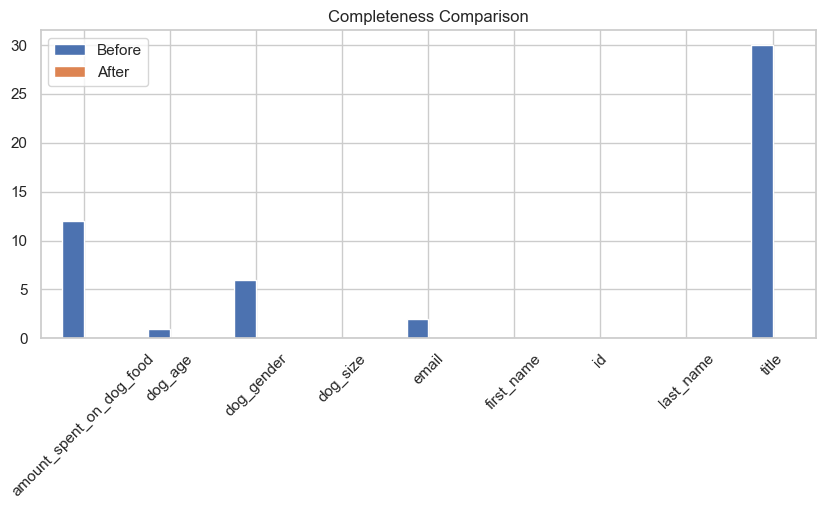

In [467]:
# Completeness comparison
comp_after = completeness_summary(df)

comp_compare = pd.DataFrame({
    'Before': comp_before['Missing Count'],
    'After': comp_after['Missing Count']
}).fillna(0)

comp_compare.plot(kind='bar', figsize=(10,4))
plt.title('Completeness Comparison')
plt.xticks(rotation=45)
plt.show()

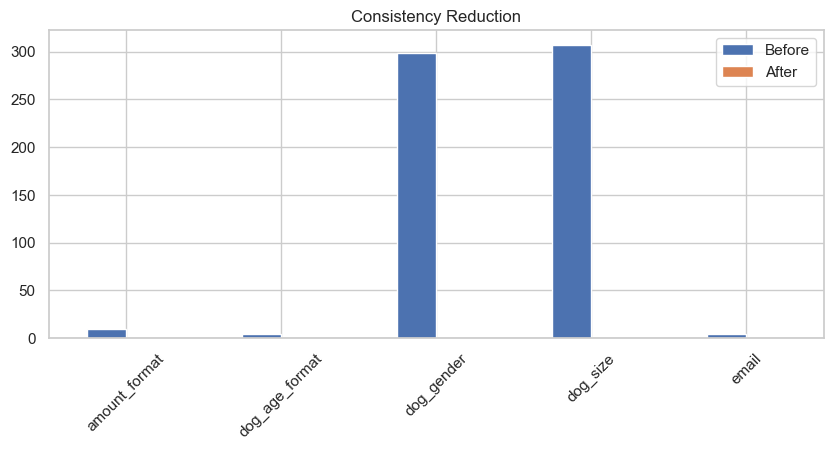

In [468]:
# Consistency comparison
summary_after, mask_after = inconsistency_summary(df)

compare = pd.DataFrame({
    'Before': summary_before['Issue Count'],
    'After': summary_after['Issue Count']
}).fillna(0)

compare.plot(kind='bar', figsize=(10,4))
plt.title('Consistency Reduction')
plt.xticks(rotation=45)
plt.show()

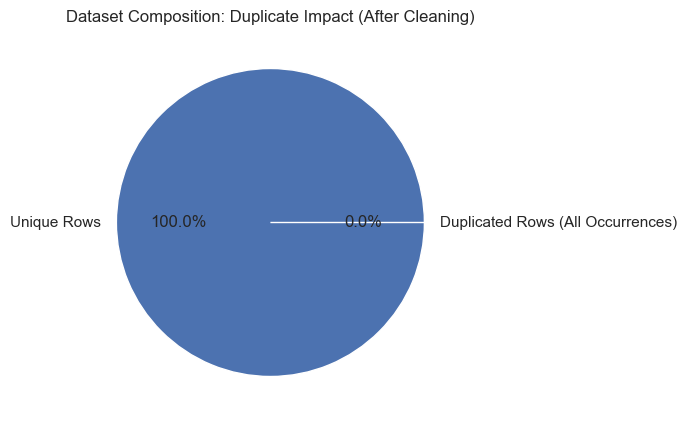

In [469]:
# Duplicate comparison
dup_mask_after = df.duplicated(keep=False)

dup_rows_after = dup_mask_after.sum()
total_rows_after = len(df)

unique_rows_after = total_rows_after - dup_rows_after

plt.figure(figsize=(5,5))
plt.pie(
    [unique_rows_after, dup_rows_after],
    labels=["Unique Rows", "Duplicated Rows (All Occurrences)"],
    autopct="%1.1f%%"
)

plt.title("Dataset Composition: Duplicate Impact (After Cleaning)")
plt.show()

## Phase 7 — Cleaning Impact

In [470]:
impact_df = pd.DataFrame(list(total_changes.items()), columns=['Step', 'Changes'])
impact_df.sort_values('Changes', ascending=False, inplace=True)
impact_df

,Step,Changes
3,amount,300
4,dog_size,300
5,dog_gender,295
1,title,30
0,duplicates_removed,8
6,dog_age,5
2,email,4


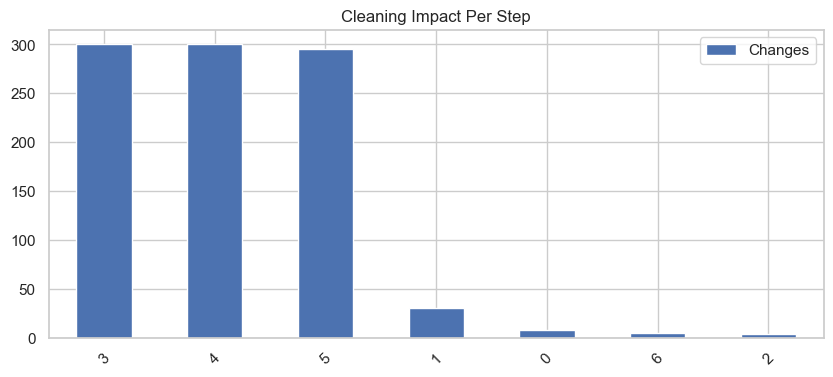

In [471]:
impact_df.plot(kind='bar', figsize=(10,4))
plt.title('Cleaning Impact Per Step')
plt.xticks(rotation=45)
plt.show()

## Export

In [472]:
df.to_csv('../../data/processed/dog_survey_cleaned.csv', index=False)
print('Export completed')

Export completed
